# 02 Walk-Forward Validation of the Multivariate Pair Trading Strategy

End-to-end evaluation of the MPTS with **rolling-window walk-forward
validation** — every fold re-calibrates the signal thresholds,
mean-reversion speed, expected returns and pair covariances on its own fixed-length
calibration window, then trades the next 12 months out-of-sample:

1. illustrate the threshold grid search on the first calibration window;
2. run the walk-forward loop;
3. per-fold diagnostics: chosen thresholds, trade counts, Sharpe dispersion;
4. stitched out-of-sample equity curve vs. buy-and-hold benchmarks.

A single 70/30 split was used in the original report; it calibrated the
thresholds once, on one market regime, and judged them on another — the
walk-forward structure replaces it.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from src import backtest, data, hedging, metrics, signals, stat_tests, walk_forward

cfg = yaml.safe_load(open("../configs/bloomberg.yaml", encoding="utf-8"))
ANCHOR = cfg["universe"]["anchor"]
EQUITIES = cfg["universe"]["equities"]
WINDOW = cfg["signals"]["zscore_window"]
WF = cfg["walk_forward"]
RF = cfg["strategy"]["risk_free_rate"]
TC = cfg["strategy"]["transaction_cost"]

In [2]:
prices = data.load_prices("../" + cfg["data"]["path"])
log_prices = data.to_log_prices(prices)

## 1. Threshold calibration: what one fold sees

Grid search over `open ∈ [1.0, 2.5)` and `close ∈ [0.5, 2.0)` (step 0.1,
`close < open` enforced) on the **first calibration window**, maximizing the
average single-spread Sharpe across the basket. The walk-forward loop
repeats this per fold and picks the *median of the top decile* (the plateau)
instead of the argmax cell, reducing per-fold selection bias.

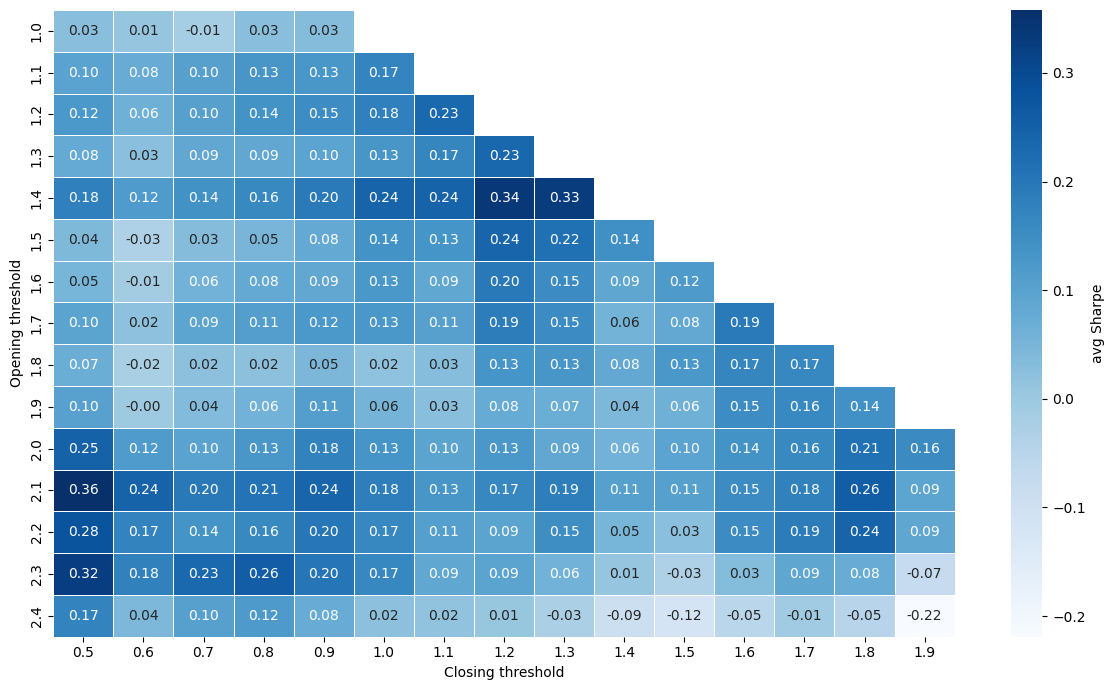

Plateau thresholds for fold 1: open=±2.1, close=±1.0


In [3]:
log_screen = data.screening_window(log_prices, WF["calibration_years"])
grid_results, heatmap = signals.grid_search_thresholds(
    log_screen, EQUITIES, ANCHOR, window=WINDOW, risk_free_rate=RF
)
open_grid = np.round(np.arange(1.0, 2.5, 0.1), 1)
close_grid = np.round(np.arange(0.5, 2.0, 0.1), 1)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=close_grid, yticklabels=open_grid,
            linewidths=0.5, cbar_kws={"label": "avg Sharpe"}, ax=ax)
ax.set_xlabel("Closing threshold")
ax.set_ylabel("Opening threshold")
plt.tight_layout()
plt.show()

plateau_open, plateau_close = walk_forward.calibrate_thresholds(
    log_screen, EQUITIES, ANCHOR, window=WINDOW, risk_free_rate=RF
)
print(f"Plateau thresholds for fold 1: open=±{plateau_open}, close=±{plateau_close}")

## 2. Run the walk-forward validation

In [4]:
CANDIDATES = [c for c in log_prices.columns
              if c not in set(cfg["universe"]["exclude"]) | {ANCHOR}]

result = walk_forward.run_walk_forward(
    log_prices, EQUITIES, ANCHOR, [ANCHOR, cfg["universe"]["sector_proxy"]],
    calibration_years=WF["calibration_years"],
    test_months=WF["test_months"],
    embargo_days=WF["embargo_days"],
    window=WINDOW,
    risk_aversion=cfg["strategy"]["risk_aversion"],
    transaction_cost=TC,
    risk_free_rate=RF,
    rolling_beta_window=cfg["strategy"]["rolling_beta_window"],
    solver=cfg["strategy"]["solver"],
    candidates=CANDIDATES,          # per-fold basket re-selection
    n_pairs=cfg["universe"]["n_pairs"],
)
result.folds.round(3)

Restricted license - for non-production use only - expires 2027-11-29
fold 1: calibrate 2016-02-12 -> 2019-12-24 | test 2020-01-23 -> 2020-12-10 | thresholds +/-2.1/+/-1.0 | 39 trades | Sharpe 1.180
fold 2: calibrate 2017-01-31 -> 2020-12-10 | test 2021-01-11 -> 2021-11-29 | thresholds +/-2.2/+/-0.7 | 29 trades | Sharpe -1.551
fold 3: calibrate 2018-01-18 -> 2021-11-29 | test 2021-12-29 -> 2022-11-16 | thresholds +/-2.2/+/-0.6 | 27 trades | Sharpe -0.707
fold 4: calibrate 2019-01-07 -> 2022-11-16 | test 2022-12-16 -> 2023-11-03 | thresholds +/-2.1/+/-0.7 | 32 trades | Sharpe 0.843
fold 5: calibrate 2019-12-25 -> 2023-11-03 | test 2023-12-05 -> 2024-10-22 | thresholds +/-1.9/+/-0.9 | 38 trades | Sharpe -0.995
fold 6: calibrate 2020-12-11 -> 2024-10-22 | test 2024-11-21 -> 2025-10-09 | thresholds +/-1.7/+/-0.6 | 44 trades | Sharpe 0.127
fold 7: calibrate 2021-11-30 -> 2025-10-09 | test 2025-11-10 -> 2026-02-12 | thresholds +/-1.2/+/-1.0 | 27 trades | Sharpe -2.329


,fold,cal_start,test_start,test_end,open_th,close_th,n_trades,sharpe,total_return
0,1,2016-02-12,2020-01-23,2020-12-10,2.1,1.0,39,1.180,0.231
1,2,2017-01-31,2021-01-11,2021-11-29,2.2,0.7,29,-1.551,-0.046
2,3,2018-01-18,2021-12-29,2022-11-16,2.2,0.6,27,-0.707,-0.001
3,4,2019-01-07,2022-12-16,2023-11-03,2.1,0.7,32,0.843,0.105
4,5,2019-12-25,2023-12-05,2024-10-22,1.9,0.9,38,-0.995,-0.133
5,6,2020-12-11,2024-11-21,2025-10-09,1.7,0.6,44,0.127,0.026
6,7,2021-11-30,2025-11-10,2026-02-12,1.2,1.0,27,-2.329,-0.039


The per-fold table is the honest headline: with ~6 annual folds, report the
**median fold Sharpe and its range**, not a single number. Note how the
chosen thresholds move across folds — threshold economics are
regime-dependent, which the single-split design could never reveal.

## 3. Stitched out-of-sample equity curve vs. benchmarks

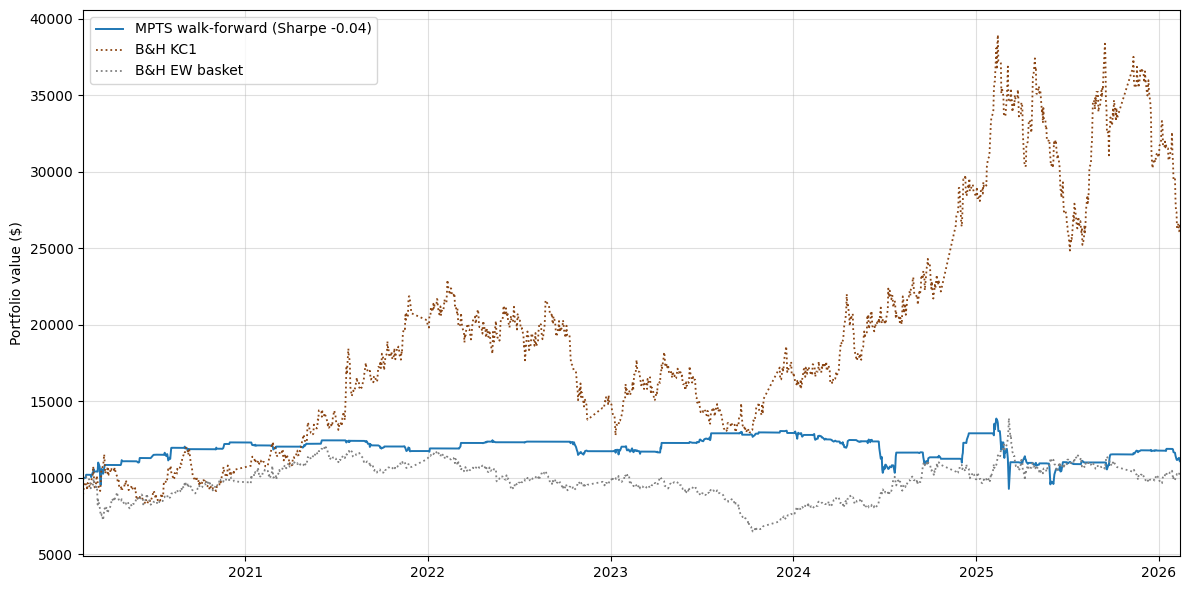

,MPTS walk-forward,B&H KC1,B&H EW basket
sharpe,-0.0394,0.5326,-0.0284
annualized_return,0.0179,0.1849,0.0066
total_return,0.1076,1.6612,0.0386
annualized_volatility,0.1729,0.3770,0.2284
max_drawdown,-0.3314,-0.4430,-0.4605


In [7]:
CAPITAL = cfg["backtest"]["initial_capital"]
log_oos = log_prices.loc[result.pnl.index]
kc1_value = backtest.buy_and_hold_benchmark(log_oos, [ANCHOR], CAPITAL, TC)
ew_value = backtest.buy_and_hold_benchmark(log_oos, EQUITIES, CAPITAL, TC)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(result.portfolio_value(CAPITAL), lw=1.4,
        label=f"MPTS walk-forward (Sharpe {result.sharpe:.2f})")
ax.plot(kc1_value, ls=":", color="saddlebrown", lw=1.3, label=f"B&H {ANCHOR}")
ax.plot(ew_value, ls=":", color="grey", lw=1.3, label="B&H EW basket")
ax.set_xlim([pd.to_datetime('2020-02-12'), pd.to_datetime('2026-02-12')])
ax.set_ylabel("Portfolio value ($)"); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

report = pd.DataFrame({
    "MPTS walk-forward": metrics.portfolio_metrics(result.portfolio_value(CAPITAL), RF),
    f"B&H {ANCHOR}": metrics.portfolio_metrics(kc1_value, RF),
    "B&H EW basket": metrics.portfolio_metrics(ew_value, RF),
})
report.round(4)

## 4. Trade-level statistics and fold dispersion

In [11]:
display(pd.Series(metrics.trade_metrics(result.trades)).round(4).to_frame("value"))
print(f"Fold Sharpe: median {result.folds['sharpe'].median():.3f}, "
      f"range [{result.folds['sharpe'].min():.3f}, {result.folds['sharpe'].max():.3f}]")

,value
n_trades,236.0000
pct_winning,0.5212
pct_losing,0.4788
pct_long_win,0.5255
pct_short_win,0.5152
win_loss_ratio,1.1328
average_win,0.0181
average_loss,-0.0160
largest_win,0.1312
largest_loss,-0.1459


Fold Sharpe: median -0.707, range [-2.329, 1.180]
